# GlitchGAN Evaluation

Evaluates the **GlitchGAN** generator (TensorFlow/Keras, epoch 210) on LIGO gravitational-wave glitch data.

**Sections:**
1. Waveform visualisation — real vs generated signals
2. UMAP 3D embedding (correlation metric, 2 000 samples per class)
3. GravitySpy classification — inject generated glitches and classify with the O3 CNN

**Prerequisites:**
- Data files in `data/` (see README for download instructions)
- GravitySpy installed; set `PATH_TO_REPO` below to your local clone


## Dependencies

Install the eval extras:

```bash
pip install "glitchgan[eval]"
```

In [ ]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve().parent
DATA_DIR     = PROJECT_ROOT / "data"
PLOTS_DIR    = PROJECT_ROOT / "evaluation_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

SEED = 42 # was 56
os.environ["PYTHONHASHSEED"] = str(SEED)

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from glitchgan.tf.model_components import ArgmaxLayer, ReduceSumDotLayer
_co = {"ArgmaxLayer": ArgmaxLayer, "ReduceSumDotLayer": ReduceSumDotLayer}

# ── Generator ─────────────────────────────────────────────────────────────────
GENERATOR_PATH  = PROJECT_ROOT / "weights" / "tensorflow" / "generator_210_keras3.keras"
GENERATOR_EPOCH = 210
NOISE_DIM       = 100
NUM_CLASSES     = 7
SAMPLES_PER_CLASS = 100

LABEL_ORDER = [
    "Blip", "Fast_Scattering", "Koi_Fish",
    "Low_Frequency_Burst", "Scattered_Light", "Tomte", "Whistle",
]

# ── GravitySpy ────────────────────────────────────────────────────────────────
IFO           = "H1"
SRATE         = 4096
GW_START      = 1262540000
GW_END        = GW_START + 40
CHANNEL       = f"{IFO}:GDS-CALIB_STRAIN"
PATH_TO_MODEL = PROJECT_ROOT / "models" / "sidd-cqg-paper-O3-model.h5"
# Update to your local GravitySpy repository clone:
PATH_TO_REPO  = "/path/to/GravitySpy"
NUM_CLASSIFY  = 10
SNR_TARGET    = 50
INIT_TIME     = -20
EVENT_TIME    = 0

print("Project root :", PROJECT_ROOT)
print("Generator    :", GENERATOR_PATH.name)
print("Model exists :", GENERATOR_PATH.exists())


Project root : /Users/tomdooney/Documents/Work/Projects/glitchgan
Generator    : generator_210_keras3.keras
Model exists : True


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
    # plt.style.use(["science"]) 
except ImportError:
    pass  # scienceplots requires LaTeX; fall back to matplotlib defaults

import random
import tensorflow as tf

# random.seed(SEED)
# np.random.seed(SEED)
# tf.random.set_seed(SEED)

## 1. Load Data

In [3]:
X_real   = np.load(DATA_DIR / "glitch_GAN_samples_scaled_balanced.npy")
y_onehot = np.load(DATA_DIR / "glitch_GAN_labels_balanced.npy")
y_real   = np.array(LABEL_ORDER)[np.argmax(y_onehot, axis=1)]

print(f"Real signals : {X_real.shape}")
print(f"Classes      : {LABEL_ORDER}")


Real signals : (35000, 8192)
Classes      : ['Blip', 'Fast_Scattering', 'Koi_Fish', 'Low_Frequency_Burst', 'Scattered_Light', 'Tomte', 'Whistle']


## 2. Load Generator

In [4]:
import keras
from glitchgan.tf import GlitchGAN

gan = GlitchGAN()
gan.generator = keras.models.load_model(str(GENERATOR_PATH), compile=False)

print(f"Loaded GlitchGAN generator from: {GENERATOR_PATH.name}")


Loaded GlitchGAN generator from: generator_210_keras3.keras


## 3. Training Loss History

Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/training_loss_history.pdf


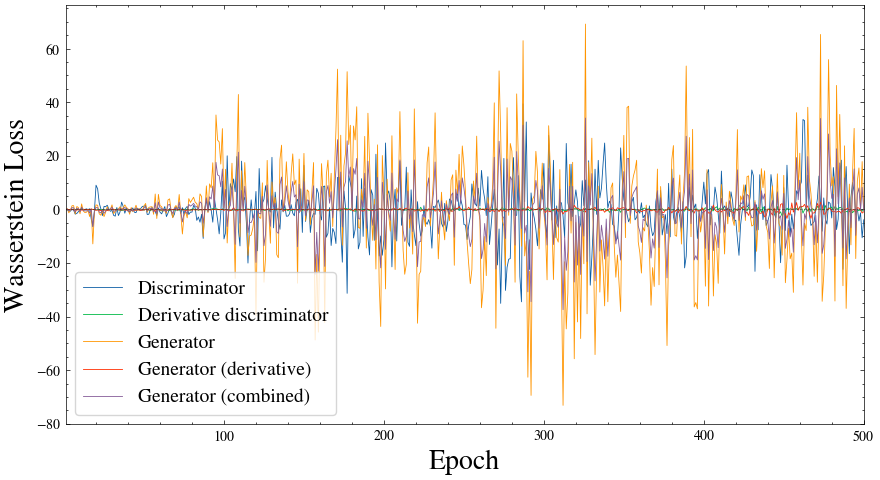

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt

HISTORY_PATH = PROJECT_ROOT / "history.json"
with open(HISTORY_PATH) as f:
    history = json.load(f)

epochs = np.arange(1, len(history["d_loss"]) + 1)
SMOOTH = 10

def smooth(x, w):
    return np.convolve(x, np.ones(w) / w, mode="valid")

epochs_s = epochs[SMOOTH - 1:]

series = [
    ("d_loss",          "Discriminator",             "C0"),
    ("d2d_loss",        "Derivative discriminator",  "C1"),
    ("g_loss",          "Generator",                 "C2"),
    ("g_loss2d",        "Generator (derivative)",    "C3"),
    ("g_loss_combined", "Generator (combined)",      "C4"),
]

fig, ax = plt.subplots(figsize=(9, 5))
for key, label, color in series:
    # ax.plot(epochs,   history[key],              color=color, alpha=0.15, lw=0.6)
    ax.plot(epochs,   history[key],              color=color, alpha=1, lw=0.6, label=label)
    # ax.plot(epochs_s, smooth(history[key], SMOOTH), color=color, lw=1.5, label=label)

ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.4)
ax.set_xlabel("Epoch", fontsize=20)
ax.set_ylabel("Wasserstein Loss", fontsize=20)
ax.set_xlim(1, 500)
ax.legend(fontsize=14, frameon=True, loc="lower left")
plt.tight_layout()
save_path = PLOTS_DIR / "training_loss_history.pdf"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()


## 4. Generate Signals

In [6]:
from glitchgan.tf.utils import generate_examples

X_fake, class_vecs = generate_examples(
    gan,
    noise_dim=NOISE_DIM,
    num_classes=NUM_CLASSES,
    num_signals=NUM_CLASSES * SAMPLES_PER_CLASS,
    sampling="vertex",
)
y_fake = np.array(LABEL_ORDER)[np.argmax(class_vecs, axis=1)]

print(f"Generated : {X_fake.shape}  ({SAMPLES_PER_CLASS} per class)")


Generated : (700, 8192)  (100 per class)


## 4. Waveform Visualisation

/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


Loaded from cache: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/strain_bg_1262540000_1262540040.hdf5


PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


white_noise: (163840,)  type: <class 'numpy.ndarray'>


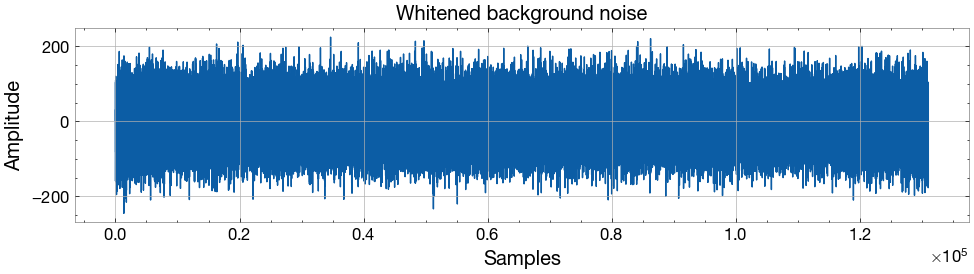

In [7]:
from gwpy.timeseries import TimeSeries
import numpy as np
import matplotlib.pyplot as plt

_bg_cache = PROJECT_ROOT / "evaluation_plots" / f"strain_bg_{GW_START}_{GW_END}.hdf5"

try:
    strain_bg = TimeSeries.read(_bg_cache, format="hdf5")
    print(f"Loaded from cache: {_bg_cache}")
except Exception:
    strain_bg = TimeSeries.fetch_open_data("H1", GW_START, GW_END)
    strain_bg = strain_bg.resample(SRATE)
    strain_bg.write(_bg_cache, format="hdf5", overwrite=True)
    print(f"Fetched and cached: {_bg_cache}")

# Match reference exactly: use gwpy's to_pycbc(), keep whitened result as pycbc TimeSeries
noise = strain_bg.to_pycbc()
white_noise_pycbc, psd = noise.whiten(
    len(noise) / (2 * SRATE),
    len(noise) / (4 * SRATE),
    remove_corrupted=False,
    return_psd=True,
)
# numpy copy for plotting / Q-scan visualisation only
white_noise = np.asarray(white_noise_pycbc)
print(f"white_noise: {white_noise.shape}  type: {type(white_noise)}")

plt.figure(figsize=(10, 3))
plt.plot(white_noise[SRATE * 4 : -SRATE * 4])
plt.xlabel("Samples"); plt.ylabel("Amplitude")
plt.title("Whitened background noise")
plt.tight_layout(); plt.show()


/var/folders/gv/z_2s63x116vbz6s2hmnl7mkc0000gn/T/ipykernel_21306/2254928735.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


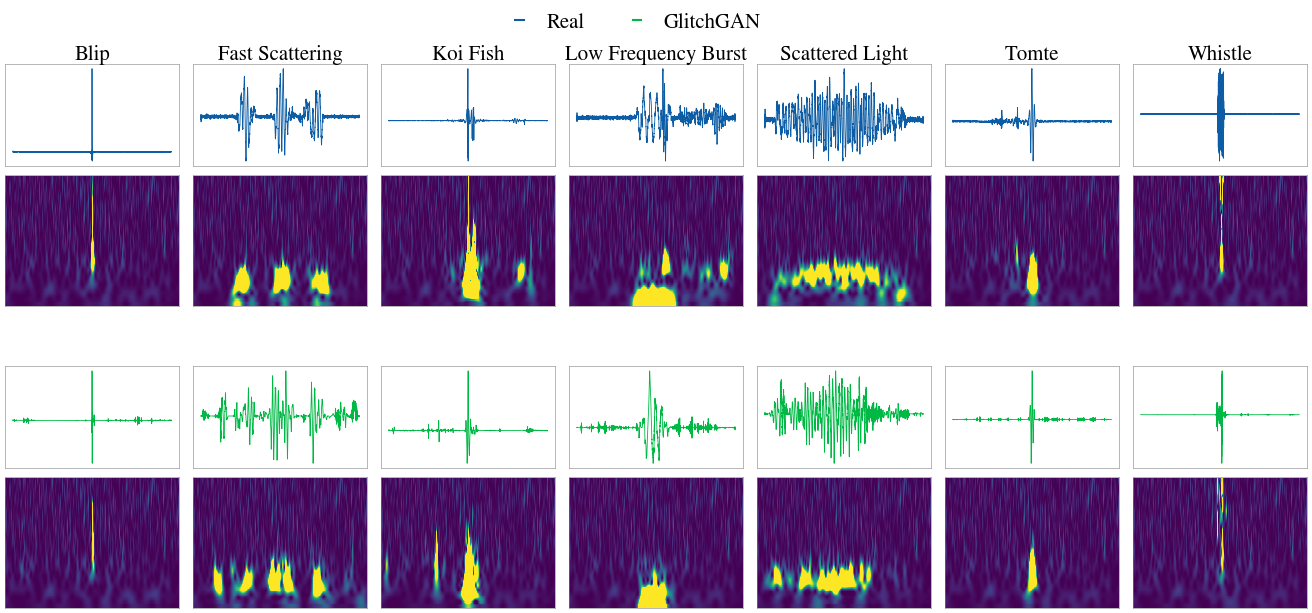

In [8]:
from matplotlib.lines import Line2D
from glitchgan.utils import plot_q_transform, whitened_snr_scaling

try:
    plt.style.use(["science", "no-latex"])  # remove "no-latex" if latex is on PATH
except Exception:
    pass

def _inject(glitch, white_noise):
    len_g    = len(glitch)
    id_start = len(white_noise) // 2 - len_g // 2
    injected = white_noise.copy()
    injected[id_start : id_start + len_g] += glitch
    return injected


def plot_comparison_grid(sources, label_order, n_examples=1, save_name=None,
                          white_noise=None, snr_default=50, snr_overrides=None):
    # Local RNG so sample selection is reproducible regardless of upstream state
    rng = np.random.default_rng(SEED)

    show_qscans    = white_noise is not None
    n_sources      = len(sources)
    n_classes      = len(label_order)
    rows_per_src   = 2 if show_qscans else 1
    n_rows         = n_sources * rows_per_src
    ts_height      = 1.4
    qs_height      = 1.8
    row_heights    = [ts_height, qs_height] * n_sources if show_qscans else [ts_height] * n_sources

    fig, axes = plt.subplots(
        n_rows, n_classes * n_examples,
        figsize=(2.4 * n_classes * n_examples, sum(row_heights)),
        gridspec_kw={"hspace": 0.08, "wspace": 0.08,
                     "height_ratios": row_heights},
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    legend_handles = []
    for src_idx, (X, y, src_label, color) in enumerate(sources):
        legend_handles.append(Line2D([0], [0], color=color, lw=1.5, label=src_label))
        ts_row = src_idx * rows_per_src
        qs_row = ts_row + 1 if show_qscans else None

        for ci, lbl in enumerate(label_order):
            idx    = np.where(y == lbl)[0]
            chosen = rng.choice(idx, min(n_examples, len(idx)), replace=False)
            snr    = (snr_overrides or {}).get(lbl, snr_default)

            for j, sample_idx in enumerate(chosen):
                col   = ci * n_examples + j
                ax_ts = axes[ts_row, col]

                ax_ts.plot(X[sample_idx], lw=0.6, color=color)
                ax_ts.set_xticks([]); ax_ts.set_yticks([])
                for spine in ax_ts.spines.values():
                    spine.set_linewidth(0.4)
                if src_idx == 0 and j == 0:
                    ax_ts.set_title(lbl.replace("_", " "), fontsize=15, pad=3)

                if show_qscans:
                    ax_qs    = axes[qs_row, col]
                    glitch   = whitened_snr_scaling(X[sample_idx], snr, srate=SRATE)
                    injected = _inject(glitch, white_noise)
                    plot_q_transform(injected, srate=SRATE, crop=(20, 2),
                                     whiten=False, ax=ax_qs, colourbar=False)
                    ax_qs.set_xlabel(""); ax_qs.set_ylabel("")
                    ax_qs.set_xticks([]); ax_qs.set_yticks([])
                    for spine in ax_qs.spines.values():
                        spine.set_linewidth(0.4)

    plt.tight_layout(rect=[0, 0, 1, 0.99])

    # Extra gap between source pairs (does not affect within-pair spacing)
    if show_qscans and n_sources > 1:
        for src_idx in range(1, n_sources):
            for row_offset in range(rows_per_src):
                row = src_idx * rows_per_src + row_offset
                for col in range(n_classes * n_examples):
                    pos = axes[row, col].get_position()
                    axes[row, col].set_position(
                        [pos.x0, pos.y0 - 0.08, pos.width, pos.height])

    fig.legend(handles=legend_handles, loc="upper center", ncol=n_sources,
               fontsize=15, frameon=False, bbox_to_anchor=(0.5, 0.99))
    if save_name:
        plt.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()


plot_comparison_grid(
    sources=[
        (X_real, y_real, "Real",      "C0"),
        (X_fake, y_fake, "GlitchGAN", "C1"),
    ],
    label_order=LABEL_ORDER,
    n_examples=1,
    white_noise=white_noise,
    snr_default=50,
    snr_overrides={"Koi_Fish": 150, "Whistle": 150},
    save_name=f"waveform_comparison_ep{GENERATOR_EPOCH}",
)


## UMAP Embedding

3D UMAP embedding (correlation metric) of 2 000 real + 2 000 fake samples per class.
Reproduces Figures 5 & 6 from the paper.


In [9]:
import tensorflow as tf

N_FULL = 2000

# Subsample real data
rng_full = np.random.default_rng(42)
real_idx = []
for lbl in LABEL_ORDER:
    cls_idx = np.where(y_real == lbl)[0]
    real_idx.extend(rng_full.choice(cls_idx, size=min(N_FULL, len(cls_idx)), replace=False))
X_real_full = X_real[real_idx]
y_real_full  = y_real[real_idx]
print(f"Real subsampled : {X_real_full.shape}")

# Generate fake data in chunks (avoids OOM on large batch)
n_fake_full = NUM_CLASSES * N_FULL
noise_full  = np.random.randn(n_fake_full, NOISE_DIM).astype("float32")
class_full  = np.repeat(np.eye(NUM_CLASSES, dtype="float32"), N_FULL, axis=0)

CHUNK = 2048
chunks_fake = []
for i in range(0, n_fake_full, CHUNK):
    out = gan.generator([noise_full[i:i+CHUNK], class_full[i:i+CHUNK]], training=False)
    chunks_fake.append(out.numpy())
X_fake_full = np.concatenate(chunks_fake, axis=0)
y_fake_full  = np.repeat(LABEL_ORDER, N_FULL)
print(f"Fake generated  : {X_fake_full.shape}")

X_all_full         = np.concatenate([X_real_full, X_fake_full], axis=0)
y_all_full         = np.concatenate([y_real_full, y_fake_full], axis=0)
domain_labels_full = np.array(["Real"] * len(X_real_full) + ["Fake"] * len(X_fake_full))
print(f"UMAP input      : {X_all_full.shape}  ({X_all_full.nbytes / 1e9:.2f} GB)")


Real subsampled : (14000, 8192)
Fake generated  : (14000, 8192)
UMAP input      : (28000, 8192)  (1.84 GB)


In [10]:
reducer_full = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.6,
    metric="correlation",
    random_state=SEED,
    low_memory=True,
)
embedding_full_corr = reducer_full.fit_transform(X_all_full)
print(f"Embedding shape : {embedding_full_corr.shape}")


/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Embedding shape : (28000, 3)


In [ ]:
low, high = 1, 99
x1, x2, x3 = embedding_full_corr[:, 0], embedding_full_corr[:, 1], embedding_full_corr[:, 2]
mask_clean = (
    (x1 >= np.percentile(x1, low))  & (x1 <= np.percentile(x1, high)) &
    (x2 >= np.percentile(x2, low))  & (x2 <= np.percentile(x2, high)) &
    (x3 >= np.percentile(x3, low))  & (x3 <= np.percentile(x3, high))
)
print(f"Removed {np.sum(~mask_clean)} outliers ({np.sum(~mask_clean)/len(mask_clean)*100:.2f}%)")

embedding_full_clean = embedding_full_corr[mask_clean]
y_all_clean          = y_all_full[mask_clean]
domain_labels_clean  = domain_labels_full[mask_clean]


Removed 1670 outliers (5.96%)


In [13]:
embedding_full_clean = embedding_full_corr
y_all_clean = y_all_full
domain_labels_clean = domain_labels_full

Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_two_views_corr_2k.pdf


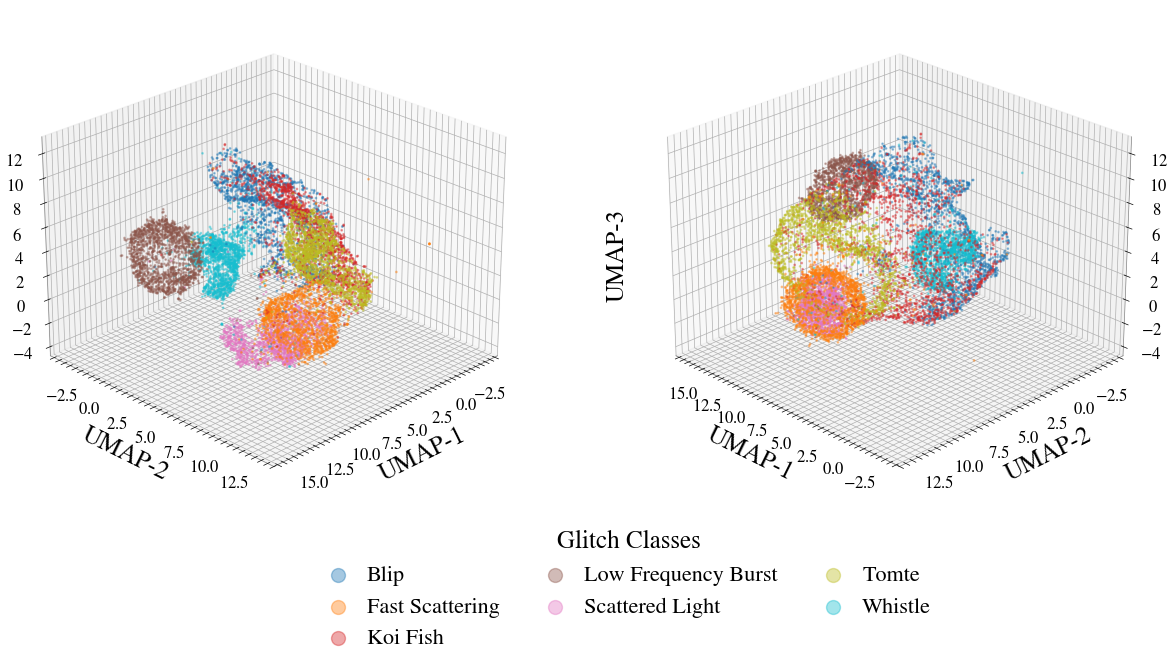

In [14]:
# ── Figure 5: two-view 3D UMAP ────────────────────────────────────────────────
from matplotlib.lines import Line2D

n_per_class = 800
plot_indices = []
for lbl in LABEL_ORDER:
    idx_real = np.where((y_all_clean == lbl) & (domain_labels_clean == "Real"))[0]
    idx_fake = np.where((y_all_clean == lbl) & (domain_labels_clean == "Fake"))[0]
    plot_indices.extend(np.random.choice(idx_real, min(len(idx_real), n_per_class), replace=False))
    plot_indices.extend(np.random.choice(idx_fake, min(len(idx_fake), n_per_class), replace=False))
plot_indices   = np.array(plot_indices)
embedding_plot = embedding_full_clean[plot_indices]
y_plot         = y_all_clean[plot_indices]
domain_plot    = domain_labels_clean[plot_indices]

unique_classes = np.array(LABEL_ORDER)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax1.view_init(elev=25, azim=45)
ax2.view_init(elev=25, azim=135)

for lbl, color in zip(unique_classes, colors):
    mask_real = (y_plot == lbl) & (domain_plot == "Real")
    mask_fake = (y_plot == lbl) & (domain_plot == "Fake")
    ax1.scatter(embedding_plot[mask_real, 0], embedding_plot[mask_real, 1], embedding_plot[mask_real, 2],
                c=[color], s=1, alpha=0.4, label=lbl.replace("_", " "))
    ax1.scatter(embedding_plot[mask_fake, 0], embedding_plot[mask_fake, 1], embedding_plot[mask_fake, 2],
                c=[color], s=1, alpha=0.4)
    ax2.scatter(embedding_plot[mask_real, 0], embedding_plot[mask_real, 1], embedding_plot[mask_real, 2],
                c=[color], s=1, alpha=0.4)
    ax2.scatter(embedding_plot[mask_fake, 0], embedding_plot[mask_fake, 1], embedding_plot[mask_fake, 2],
                c=[color], s=1, alpha=0.4)

ax1.set_xlabel("UMAP-1", fontsize=18); ax1.set_ylabel("UMAP-2", fontsize=18); ax1.set_zlabel("UMAP-3", fontsize=18)
ax2.set_xlabel("UMAP-1", fontsize=18); ax2.set_ylabel("UMAP-2", fontsize=18)
ax2.text2D(-0.05, 0.5, "UMAP-3", transform=ax2.transAxes, fontsize=18,
           rotation=90, ha="center", va="center")

handles, labels_leg = ax1.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=len(unique_classes) // 2,
           fontsize=16, title="Glitch Classes", title_fontsize=18,
           frameon=False, bbox_to_anchor=(0.45, 0.02), markerscale=10)

plt.tight_layout(rect=[0, 0.12, 0.83, 1.3])
plt.subplots_adjust(wspace=0.25)
save_path = PLOTS_DIR / "umap_two_views_corr_2k.pdf"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()


Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_per_class_corr_2k.pdf


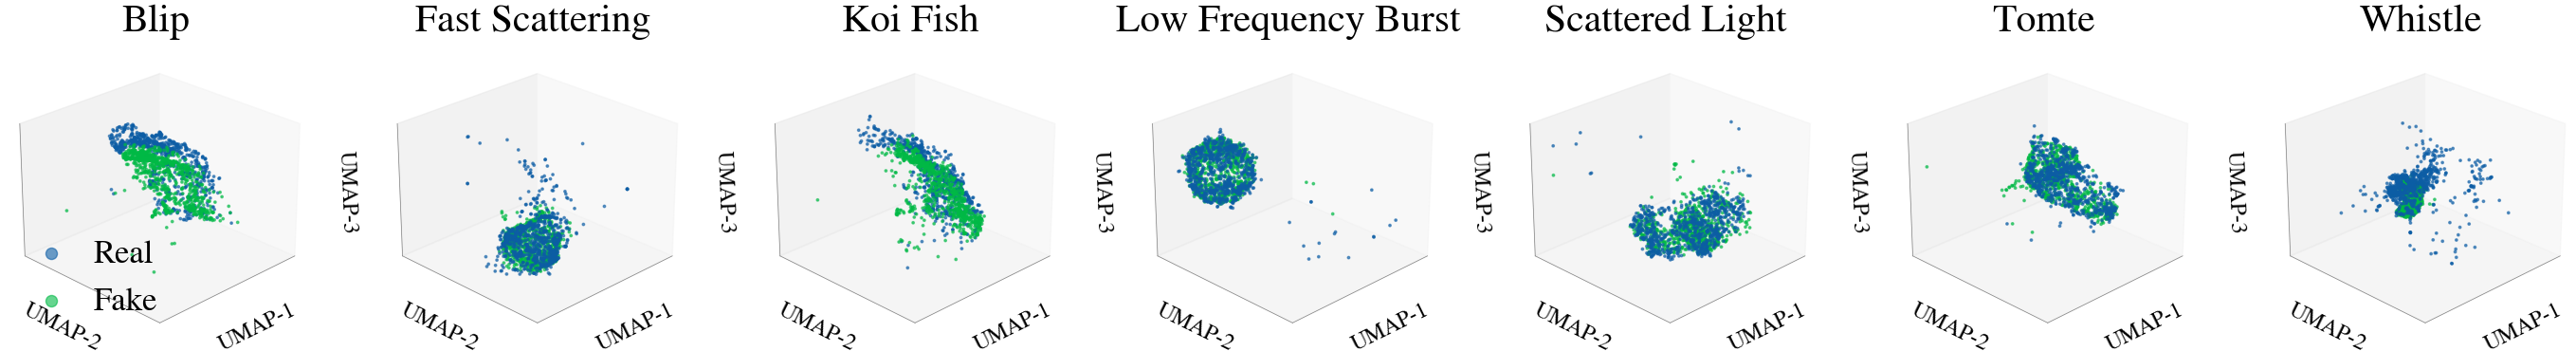

In [15]:
# ── Figure 6: per-class 3D UMAP ──────────────────────────────────────────────
fig = plt.figure(figsize=(4 * len(unique_classes), 5))

for i, lbl in enumerate(unique_classes):
    ax = fig.add_subplot(1, len(unique_classes), i + 1, projection="3d")
    mask_real = (y_plot == lbl) & (domain_plot == "Real")
    mask_fake = (y_plot == lbl) & (domain_plot == "Fake")
    ax.scatter(embedding_plot[mask_real, 0], embedding_plot[mask_real, 1], embedding_plot[mask_real, 2],
               c="C0", label="Real", s=3, alpha=0.6)
    ax.scatter(embedding_plot[mask_fake, 0], embedding_plot[mask_fake, 1], embedding_plot[mask_fake, 2],
               c="C1", label="Fake", s=3, alpha=0.6)
    ax.view_init(elev=25, azim=45)
    ax.set_xlabel("UMAP-1", fontsize=17, labelpad=2)
    ax.set_ylabel("UMAP-2", fontsize=17, labelpad=2)
    ax.set_zlabel("UMAP-3", fontsize=17, labelpad=2)
    ax.set_title(lbl.replace("_", " "), fontsize=30, pad=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    # if i == len(unique_classes) - 1:
    #     ax.legend(fontsize=25, loc="upper right", markerscale=1.5, frameon=False)
    if i == 0:    
        ax.legend(fontsize=25, loc="lower left", markerscale=5, frameon=False)

plt.tight_layout(rect=[0.01, 0.01, 0.99, 1.1])
plt.subplots_adjust(wspace=0.25)
save_path = PLOTS_DIR / "umap_per_class_corr_2k.pdf"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()


Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_per_class_corr_2k_view2.pdf


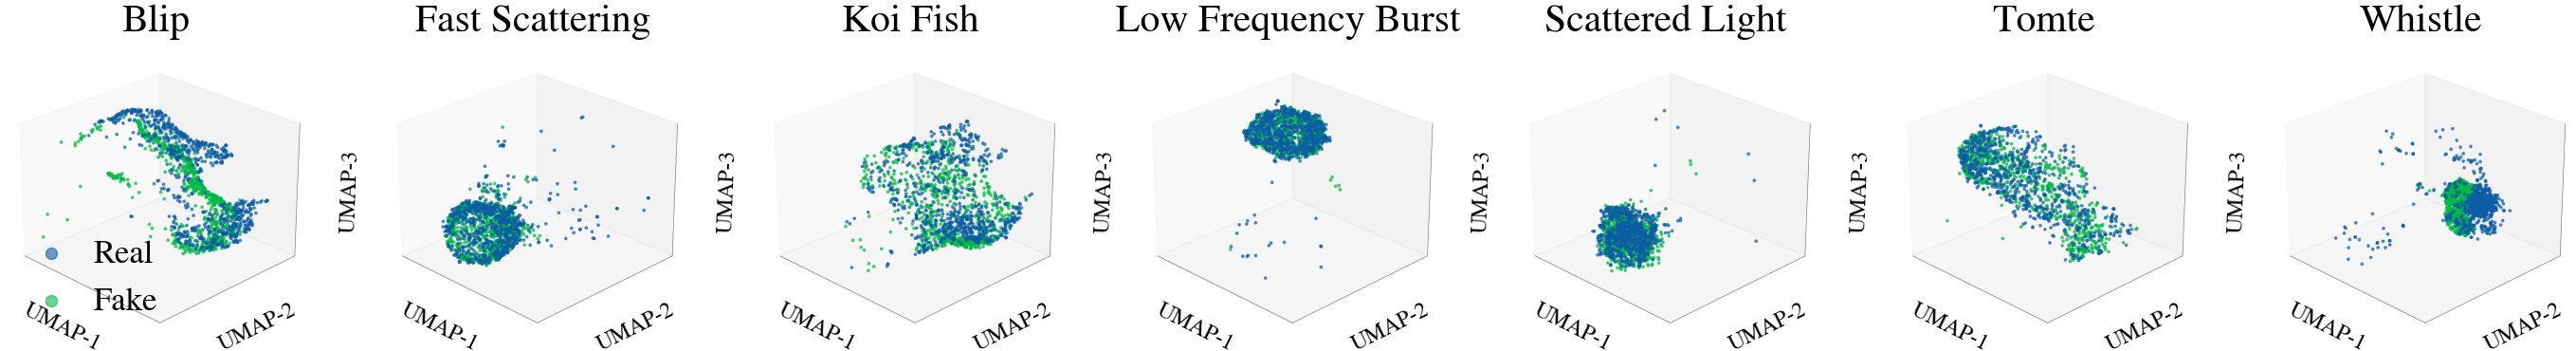

In [20]:
# ── Figure 6b: per-class 3D UMAP, second view (matches Figure 5's ax2) ───────
fig = plt.figure(figsize=(4 * len(unique_classes), 5))

for i, lbl in enumerate(unique_classes):
    ax = fig.add_subplot(1, len(unique_classes), i + 1, projection="3d")
    mask_real = (y_plot == lbl) & (domain_plot == "Real")
    mask_fake = (y_plot == lbl) & (domain_plot == "Fake")
    ax.scatter(embedding_plot[mask_real, 0], embedding_plot[mask_real, 1], embedding_plot[mask_real, 2],
               c="C0", label="Real", s=3, alpha=0.6)
    ax.scatter(embedding_plot[mask_fake, 0], embedding_plot[mask_fake, 1], embedding_plot[mask_fake, 2],
               c="C1", label="Fake", s=3, alpha=0.6)
    ax.view_init(elev=25, azim=135)
    ax.set_xlabel("UMAP-1", fontsize=17, labelpad=2)
    ax.set_ylabel("UMAP-2", fontsize=17, labelpad=2)
    ax.set_zlabel("UMAP-3", fontsize=17, labelpad=2)
    ax.set_title(lbl.replace("_", " "), fontsize=30, pad=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    if i == 0:
        ax.legend(fontsize=25, loc="lower left", markerscale=5, frameon=False)

plt.tight_layout(rect=[0.01, 0.01, 0.99, 1.1])
plt.subplots_adjust(wspace=0.25)
save_path = PLOTS_DIR / "umap_per_class_corr_2k_view2.pdf"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()


## UMAP Stability Analysis (multiple seeds & hyperparameters)

Re-fits the same 3D correlation-metric UMAP embedding across a grid of `random_state`
seeds and `(n_neighbors, min_dist)` hyperparameter pairs, holding the underlying
real/fake sample pool (`X_all_full`/`y_all_full`/`domain_labels_full` from the
"UMAP Embedding" section above) fixed. Only UMAP's own stochastic optimisation and
hyperparameters vary across the grid, so a consistent real/fake overlap-or-separation
pattern per class is evidence the Figure 5/6 conclusions aren't an artifact of one
particular embedding.

Reuses the same plotting logic as Figures 5 & 6, refactored into functions, and plots
the same *fixed* subsample of points at every grid point (selected once, before the
sweep) so differences between panels are attributable only to the embedding itself.

This is compute-heavy: each grid point is one full UMAP fit on the same
`(28000, 8192)` input as the main embedding above. Shrink `STABILITY_SEEDS` /
`HYPERPARAM_GRID` for a quick check before running the full grid.

In [32]:
# ── Reusable plotting functions (refactored from Figures 5 & 6 above) ────────
from matplotlib.lines import Line2D


def plot_two_views(embedding, y, domain, label_order, save_name, azims=(45, 135), elev=25):
    """Figure-5-style two-panel 3D scatter, colored by class, Real+Fake overlaid."""
    unique_classes = np.array(label_order)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax1.view_init(elev=elev, azim=azims[0])
    ax2.view_init(elev=elev, azim=azims[1])

    for lbl, color in zip(unique_classes, colors):
        mask_real = (y == lbl) & (domain == "Real")
        mask_fake = (y == lbl) & (domain == "Fake")
        ax1.scatter(embedding[mask_real, 0], embedding[mask_real, 1], embedding[mask_real, 2],
                    c=[color], s=1, alpha=0.4, label=lbl.replace("_", " "))
        ax1.scatter(embedding[mask_fake, 0], embedding[mask_fake, 1], embedding[mask_fake, 2],
                    c=[color], s=1, alpha=0.4)
        ax2.scatter(embedding[mask_real, 0], embedding[mask_real, 1], embedding[mask_real, 2],
                    c=[color], s=1, alpha=0.4)
        ax2.scatter(embedding[mask_fake, 0], embedding[mask_fake, 1], embedding[mask_fake, 2],
                    c=[color], s=1, alpha=0.4)

    ax1.set_xlabel("UMAP-1", fontsize=18); ax1.set_ylabel("UMAP-2", fontsize=18); ax1.set_zlabel("UMAP-3", fontsize=18)
    ax2.set_xlabel("UMAP-1", fontsize=18); ax2.set_ylabel("UMAP-2", fontsize=18)
    ax2.text2D(-0.05, 0.5, "UMAP-3", transform=ax2.transAxes, fontsize=18,
               rotation=90, ha="center", va="center")

    handles, labels_leg = ax1.get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="lower center", ncol=len(unique_classes) // 2,
               fontsize=16, title="Glitch Classes", title_fontsize=18,
               frameon=False, bbox_to_anchor=(0.45, 0.02), markerscale=10)

    plt.tight_layout(rect=[0, 0.12, 0.83, 1.3])
    plt.subplots_adjust(wspace=0.25)
    fig.savefig(save_name, bbox_inches="tight")
    plt.close(fig)


def plot_per_class(embedding, y, domain, label_order, save_name, azim=45, elev=25):
    """Figure-6-style one-panel-per-class 3D scatter, Real vs Fake."""
    unique_classes = np.array(label_order)
    fig = plt.figure(figsize=(4 * len(unique_classes), 5))

    for i, lbl in enumerate(unique_classes):
        ax = fig.add_subplot(1, len(unique_classes), i + 1, projection="3d")
        mask_real = (y == lbl) & (domain == "Real")
        mask_fake = (y == lbl) & (domain == "Fake")
        ax.scatter(embedding[mask_real, 0], embedding[mask_real, 1], embedding[mask_real, 2],
                   c="C0", label="Real", s=3, alpha=0.6)
        ax.scatter(embedding[mask_fake, 0], embedding[mask_fake, 1], embedding[mask_fake, 2],
                   c="C1", label="Fake", s=3, alpha=0.6)
        ax.view_init(elev=elev, azim=azim)
        ax.set_xlabel("UMAP-1", fontsize=17, labelpad=2)
        ax.set_ylabel("UMAP-2", fontsize=17, labelpad=2)
        ax.set_zlabel("UMAP-3", fontsize=17, labelpad=2)
        ax.set_title(lbl.replace("_", " "), fontsize=30, pad=10)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        if i == 0:
            ax.legend(fontsize=25, loc="lower left", markerscale=5, frameon=False)

    plt.tight_layout(rect=[0.01, 0.01, 0.99, 1.1])
    plt.subplots_adjust(wspace=0.25)
    fig.savefig(save_name, bbox_inches="tight")
    plt.close(fig)


def plot_three_views_2d(embedding, y, domain, label_order, save_name, view_pairs=((0, 1), (0, 2), (1, 2))):
    """2D analogue of plot_two_views: three panels, one per UMAP view pair,
    colored by class -- matches Figure 5 (2D)'s layout/legend fix below."""
    unique_classes = np.array(label_order)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    for ax, (i, j) in zip(axes, view_pairs):
        for lbl, color in zip(unique_classes, colors):
            mask_real = (y == lbl) & (domain == "Real")
            mask_fake = (y == lbl) & (domain == "Fake")
            ax.scatter(embedding[mask_real, i], embedding[mask_real, j],
                       c=[color], s=1, alpha=0.4, label=lbl.replace("_", " "))
            ax.scatter(embedding[mask_fake, i], embedding[mask_fake, j],
                       c=[color], s=1, alpha=0.4)
        ax.set_xlabel(f"UMAP-{i+1}", fontsize=18)
        ax.set_ylabel(f"UMAP-{j+1}", fontsize=18)

    plt.tight_layout(rect=[0, 0.22, 1, 1])
    plt.subplots_adjust(wspace=0.25)
    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="lower center", ncol=len(unique_classes) // 2,
               fontsize=16, title="Glitch Classes", title_fontsize=18,
               frameon=False, bbox_to_anchor=(0.5, 0.0), markerscale=10)
    fig.savefig(save_name, bbox_inches="tight")
    plt.close(fig)


def plot_per_class_2d_grid(embedding, y, domain, label_order, view_pair, save_name, ticks=False):
    """2D analogue of plot_per_class: one panel per class, Real vs Fake, for a
    single UMAP view pair -- matches Figure 6 (2D)'s style below."""
    i, j = view_pair
    unique_classes = np.array(label_order)
    fig, axes = plt.subplots(1, len(unique_classes), figsize=(4 * len(unique_classes), 5))

    for ax, lbl in zip(axes, unique_classes):
        mask_real = (y == lbl) & (domain == "Real")
        mask_fake = (y == lbl) & (domain == "Fake")
        ax.scatter(embedding[mask_real, i], embedding[mask_real, j],
                   c="C0", label="Real", s=3, alpha=0.6)
        ax.scatter(embedding[mask_fake, i], embedding[mask_fake, j],
                   c="C1", label="Fake", s=3, alpha=0.6)
        ax.set_xlabel(f"UMAP-{i+1}", fontsize=17, labelpad=2)
        ax.set_ylabel(f"UMAP-{j+1}", fontsize=17, labelpad=2)
        ax.set_title(lbl.replace("_", " "), fontsize=30, pad=10)
        if not ticks:
            ax.set_xticks([]); ax.set_yticks([])

    axes[0].legend(fontsize=25, loc="upper right", markerscale=5, frameon=False)
    plt.tight_layout(rect=[0.01, 0.01, 0.99, 1.05])
    plt.subplots_adjust(wspace=0.25)
    fig.savefig(save_name, bbox_inches="tight")
    plt.close(fig)

In [17]:
# ── Fixed sample subset for cross-run comparison ──────────────────────────────
# Same n_per_class convention as Figures 5/6 above, but selected once from the
# full real/fake pool so every grid point below plots the exact same points --
# any visual difference across the grid is then attributable only to UMAP's
# seed/hyperparameters, not to a different random subsample each time.
N_PER_CLASS_STABILITY = 800
_stability_rng = np.random.default_rng(SEED)

stability_indices = []
for lbl in LABEL_ORDER:
    idx_real = np.where((y_all_full == lbl) & (domain_labels_full == "Real"))[0]
    idx_fake = np.where((y_all_full == lbl) & (domain_labels_full == "Fake"))[0]
    stability_indices.extend(_stability_rng.choice(idx_real, min(len(idx_real), N_PER_CLASS_STABILITY), replace=False))
    stability_indices.extend(_stability_rng.choice(idx_fake, min(len(idx_fake), N_PER_CLASS_STABILITY), replace=False))
stability_indices = np.array(stability_indices)

y_stability      = y_all_full[stability_indices]
domain_stability = domain_labels_full[stability_indices]
print(f"Fixed stability subsample: {len(stability_indices)} points "
      f"({N_PER_CLASS_STABILITY} real + {N_PER_CLASS_STABILITY} fake per class, capped by class size)")

Fixed stability subsample: 11200 points (800 real + 800 fake per class, capped by class size)


In [33]:
# ── Multi-seed / multi-hyperparameter sweep ───────────────────────────────────
# Same STABILITY_SEEDS/HYPERPARAM_GRID/stability_indices as the 3D sweep above --
# the 2D views aren't a separate UMAP fit, they're just different axis-pairs of
# the same 3-component embedding, so this loop now also emits the 2D figures
# from the embedding it already has in hand each iteration, instead of paying
# for a second round of UMAP fits. embedding_sub is cached to disk per grid
# point too, so any *future* figure additions can be regenerated without
# re-fitting UMAP at all.
import time

STABILITY_SEEDS  = [0, 1, 2]           # UMAP random_state values to test
HYPERPARAM_GRID  = [
    dict(n_neighbors=15, min_dist=0.6),   # matches the Figure 5/6 default above
    dict(n_neighbors=30, min_dist=0.3),
    dict(n_neighbors=50, min_dist=0.1),
]
STABILITY_METRIC = "correlation"  # held fixed, matches the "_corr_" naming above

STABILITY_DIR = PLOTS_DIR / "umap_stability"
os.makedirs(STABILITY_DIR, exist_ok=True)

STABILITY_2D_VIEW_PAIRS = [(0, 1), (0, 2), (1, 2)]

n_runs = len(STABILITY_SEEDS) * len(HYPERPARAM_GRID)
print(f"Running {n_runs} UMAP fits on the same {X_all_full.shape} input "
      f"({len(STABILITY_SEEDS)} seeds x {len(HYPERPARAM_GRID)} hyperparameter settings)...")

t_start = time.time()
for seed in STABILITY_SEEDS:
    for hp in HYPERPARAM_GRID:
        tag = f"seed{seed}_nn{hp['n_neighbors']}_md{hp['min_dist']}"
        t0 = time.time()

        reducer = umap.UMAP(
            n_components=3,
            n_neighbors=hp["n_neighbors"],
            min_dist=hp["min_dist"],
            metric=STABILITY_METRIC,
            random_state=seed,
            low_memory=True,
        )
        embedding = reducer.fit_transform(X_all_full)
        embedding_sub = embedding[stability_indices]

        np.savez_compressed(
            STABILITY_DIR / f"embedding_{tag}.npz",
            embedding_sub=embedding_sub, y=y_stability, domain=domain_stability,
        )

        # 3D figures
        plot_two_views(
            embedding_sub, y_stability, domain_stability, LABEL_ORDER,
            save_name=STABILITY_DIR / f"umap_two_views_corr_2k_{tag}.pdf",
        )
        plot_per_class(
            embedding_sub, y_stability, domain_stability, LABEL_ORDER,
            save_name=STABILITY_DIR / f"umap_per_class_corr_2k_{tag}.pdf", azim=45,
        )
        plot_per_class(
            embedding_sub, y_stability, domain_stability, LABEL_ORDER,
            save_name=STABILITY_DIR / f"umap_per_class_corr_2k_{tag}_view2.pdf", azim=135,
        )

        # 2D figures -- same embedding, just different axis-pairs
        plot_three_views_2d(
            embedding_sub, y_stability, domain_stability, LABEL_ORDER,
            save_name=STABILITY_DIR / f"umap_three_views_2d_corr_2k_{tag}.pdf",
            view_pairs=STABILITY_2D_VIEW_PAIRS,
        )
        for (vi, vj) in STABILITY_2D_VIEW_PAIRS:
            plot_per_class_2d_grid(
                embedding_sub, y_stability, domain_stability, LABEL_ORDER,
                view_pair=(vi, vj),
                save_name=STABILITY_DIR / f"umap_per_class_2d_corr_2k_{tag}_v{vi+1}{vj+1}.pdf",
            )

        print(f"  [{tag}] done in {time.time() - t0:.0f}s")

n_3d_figs = n_runs * (1 + 2)
n_2d_figs = n_runs * (1 + len(STABILITY_2D_VIEW_PAIRS))
print(f"Saved {n_3d_figs} 3D figures + {n_2d_figs} 2D figures + {n_runs} cached embeddings "
     f"to {STABILITY_DIR} (total {time.time() - t_start:.0f}s)")

Running 9 UMAP fits on the same (28000, 8192) input (3 seeds x 3 hyperparameter settings)...


/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  [seed0_nn15_md0.6] done in 85s


/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  [seed0_nn30_md0.3] done in 204s


...

  [seed2_nn15_md0.6] done in 88s


/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  [seed2_nn30_md0.3] done in 202s


/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  [seed2_nn50_md0.1] done in 398s
Saved 27 3D figures + 36 2D figures + 9 cached embeddings to /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_stability (total 2070s)


## 2D plots

Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_three_views_2d_corr_2k.pdf


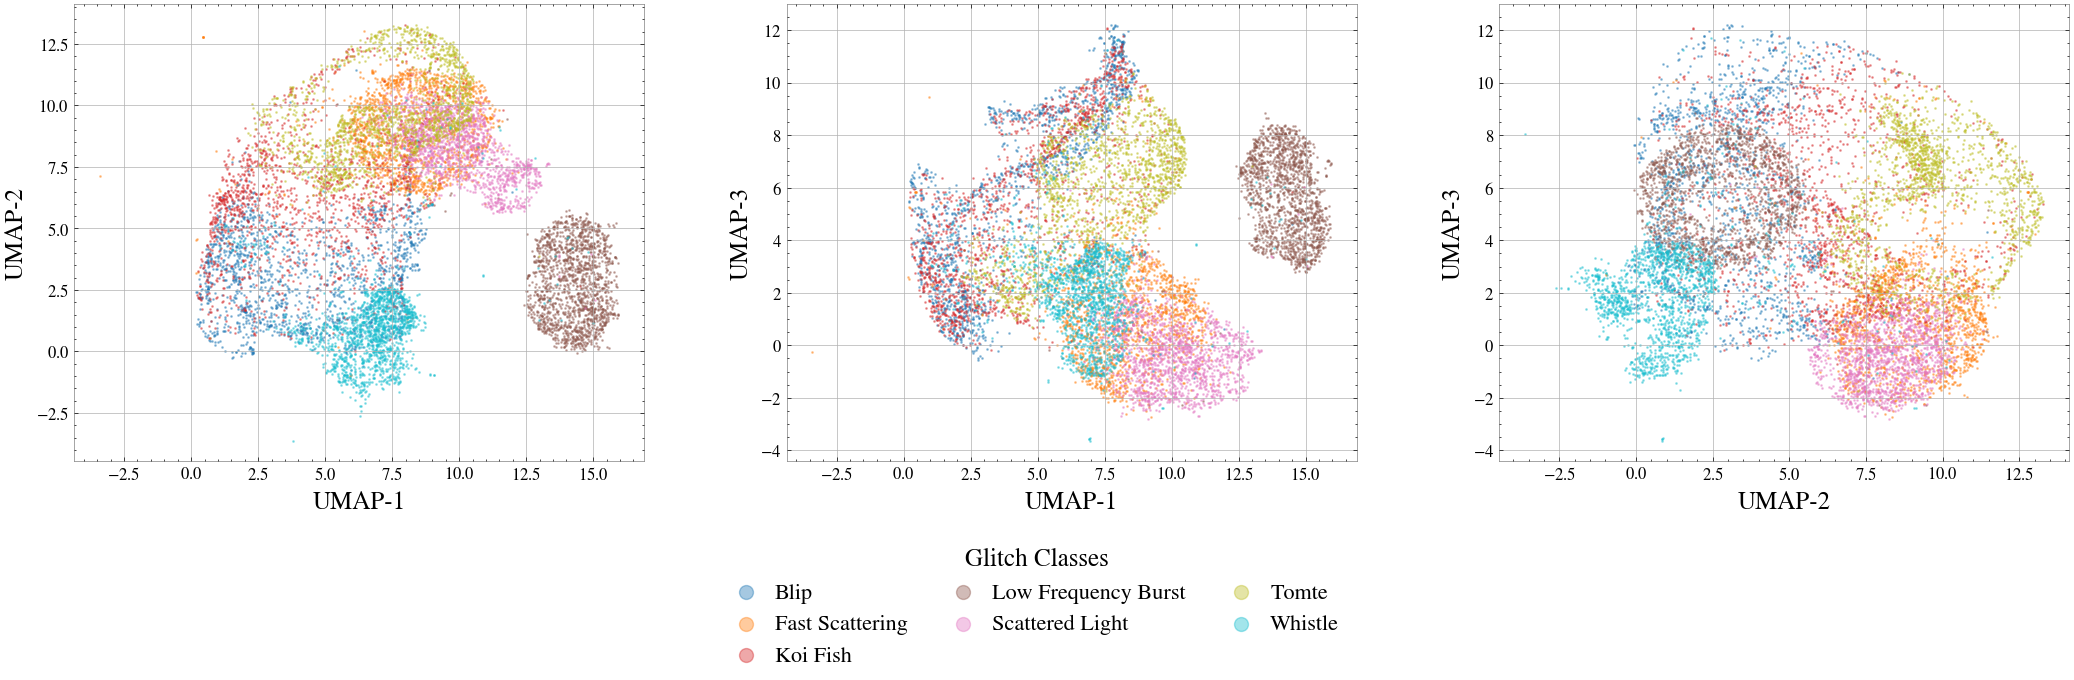

In [34]:
# ── Figure 5 (2D): three-view UMAP, colored by class ─────────────────────────
unique_classes = np.array(LABEL_ORDER)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

view_pairs = [(0, 1), (0, 2), (1, 2)]  # (UMAP-1, UMAP-2), (UMAP-1, UMAP-3), (UMAP-2, UMAP-3)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (i, j) in zip(axes, view_pairs):
    for lbl, color in zip(unique_classes, colors):
        mask_real = (y_plot == lbl) & (domain_plot == "Real")
        mask_fake = (y_plot == lbl) & (domain_plot == "Fake")
        ax.scatter(embedding_plot[mask_real, i], embedding_plot[mask_real, j],
                   c=[color], s=1, alpha=0.4, label=lbl.replace("_", " "))
        ax.scatter(embedding_plot[mask_fake, i], embedding_plot[mask_fake, j],
                   c=[color], s=1, alpha=0.4)
    ax.set_xlabel(f"UMAP-{i+1}", fontsize=18)
    ax.set_ylabel(f"UMAP-{j+1}", fontsize=18)

# Layout + legend space reserved *before* the legend is added, so tight_layout
# doesn't grow the axes into the area the legend needs (that's what was pushing
# the legend up over the middle panel). rect bottom=0.22 leaves enough room
# below the x-axis labels for the legend's own height -- verified clean with
# a synthetic-data smoke test (bottom=0.14 was not enough margin).
plt.tight_layout(rect=[0, 0.22, 1, 1])
plt.subplots_adjust(wspace=0.25)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=len(unique_classes) // 2,
           fontsize=16, title="Glitch Classes", title_fontsize=18,
           frameon=False, bbox_to_anchor=(0.5, 0.0), markerscale=10)

save_path = PLOTS_DIR / "umap_three_views_2d_corr_2k.pdf"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

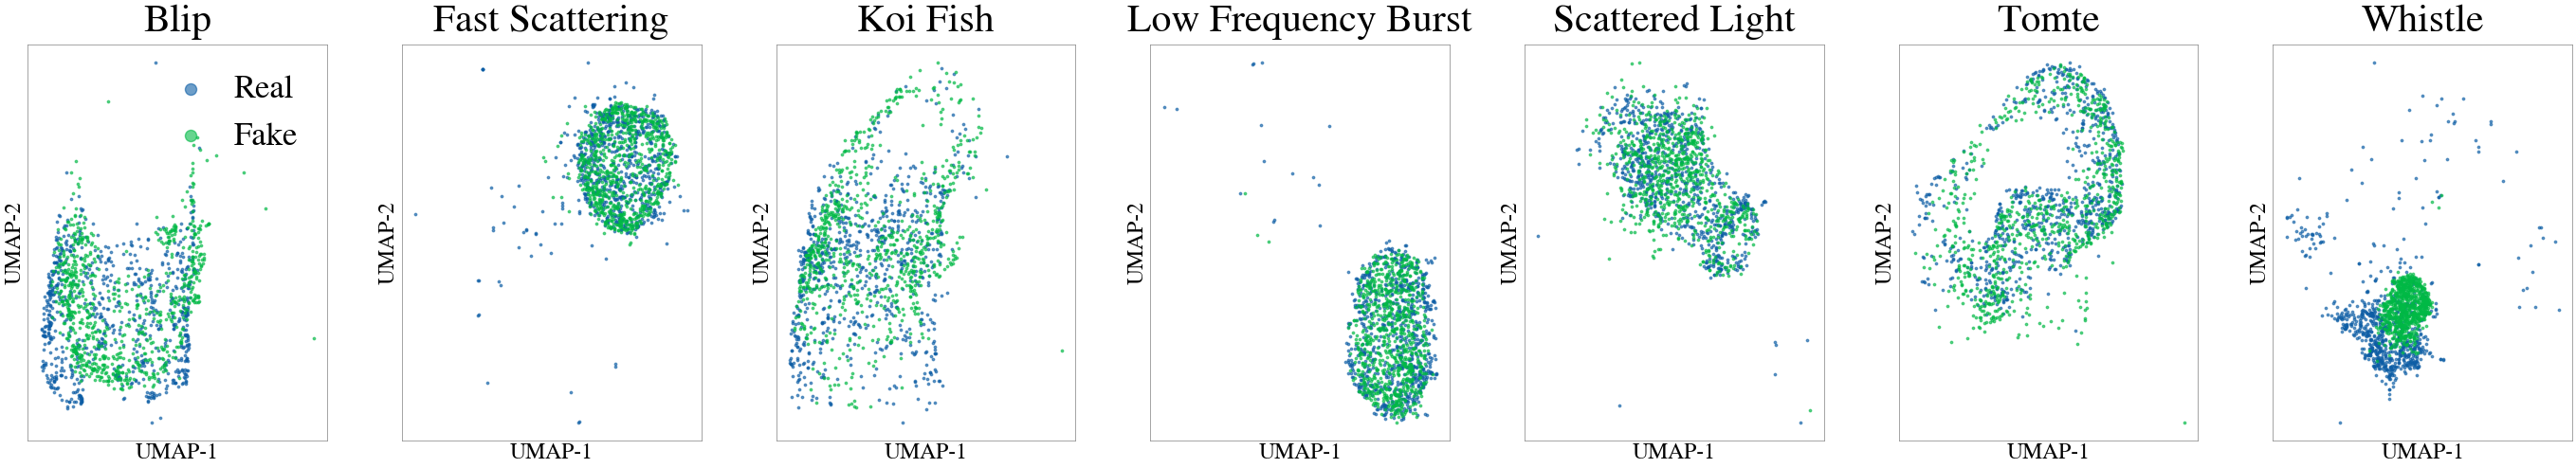

Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_per_class_2d_corr_2k_v12.pdf


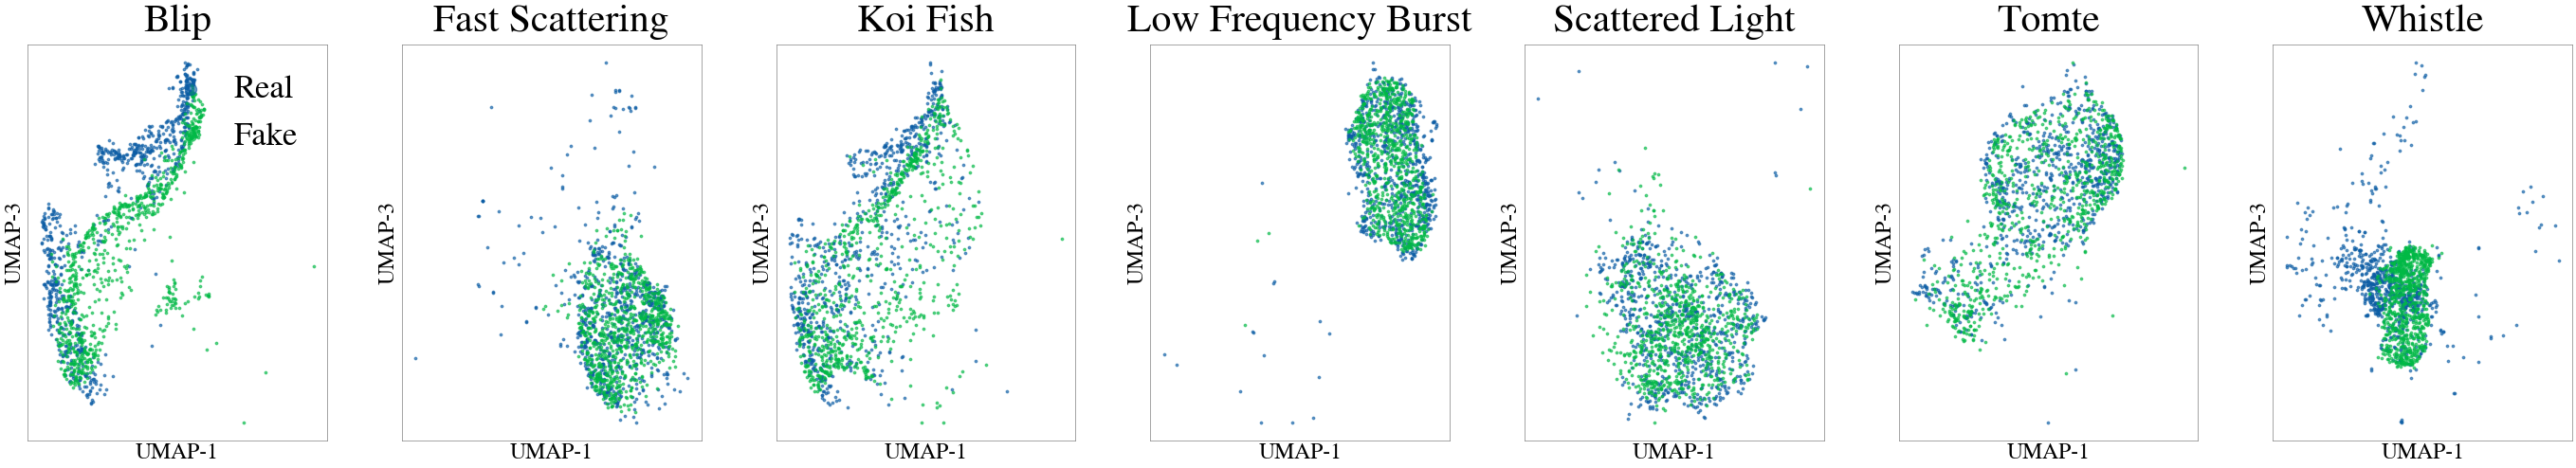

Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_per_class_2d_corr_2k_v13.pdf


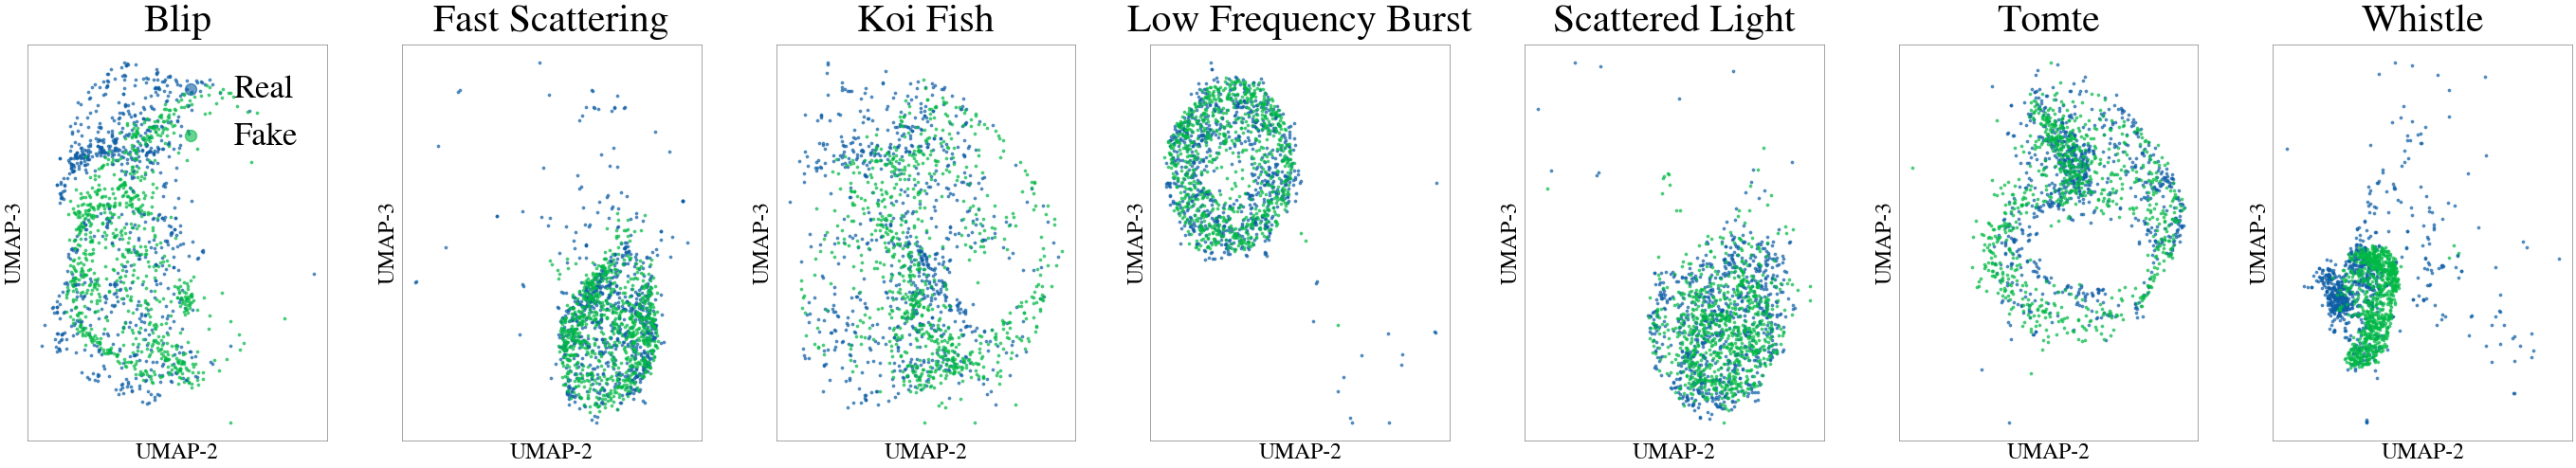

Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_per_class_2d_corr_2k_v23.pdf


In [31]:
# ── Figure 6 (2D): per-class UMAP, Real vs Fake, one figure per view pair ────
def plot_per_class_2d(embedding, y, domain, label_order, view_pair, save_name, ticks=False):
    """2D analogue of the 3D per-class figure above: one panel per class, Real
    vs Fake, for a single UMAP view pair (i, j)."""
    i, j = view_pair
    unique_classes = np.array(label_order)
    fig, axes = plt.subplots(1, len(unique_classes), figsize=(4 * len(unique_classes), 5))

    for ax, lbl in zip(axes, unique_classes):
        mask_real = (y == lbl) & (domain == "Real")
        mask_fake = (y == lbl) & (domain == "Fake")
        ax.scatter(embedding[mask_real, i], embedding[mask_real, j],
                   c="C0", label="Real", s=3, alpha=0.6)
        ax.scatter(embedding[mask_fake, i], embedding[mask_fake, j],
                   c="C1", label="Fake", s=3, alpha=0.6)
        ax.set_xlabel(f"UMAP-{i+1}", fontsize=17, labelpad=2)
        ax.set_ylabel(f"UMAP-{j+1}", fontsize=17, labelpad=2)
        ax.set_title(lbl.replace("_", " "), fontsize=30, pad=10)
        if not ticks:
            ax.set_xticks([]); ax.set_yticks([])

    axes[0].legend(fontsize=25, loc="upper right", markerscale=5, frameon=False)

    plt.tight_layout(rect=[0.01, 0.01, 0.99, 1.05])
    plt.subplots_adjust(wspace=0.25)
    fig.savefig(save_name, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for (i, j) in view_pairs:
    out_path = PLOTS_DIR / f"umap_per_class_2d_corr_2k_v{i+1}{j+1}.pdf"
    plot_per_class_2d(embedding_plot, y_plot, domain_plot, LABEL_ORDER,
                      view_pair=(i, j), save_name=out_path, ticks=False)
    print(f"Saved: {out_path}")

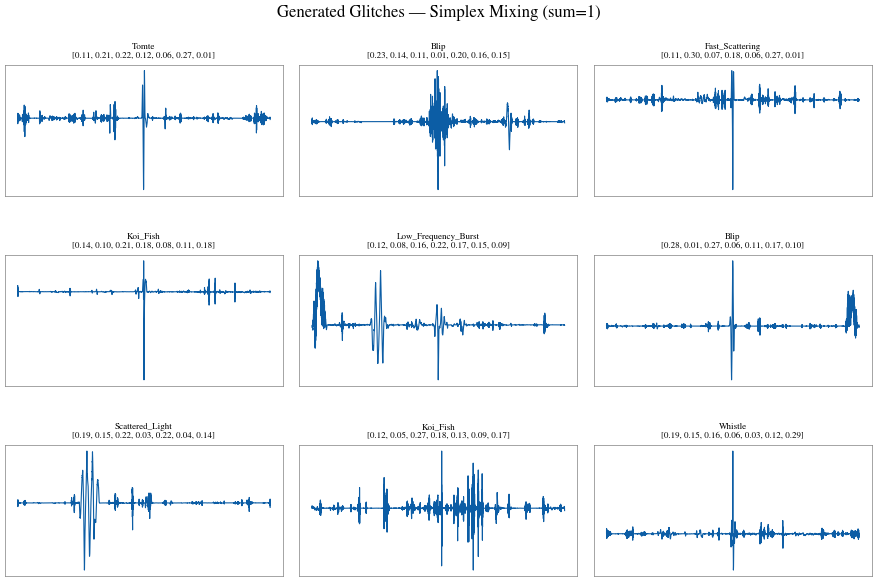

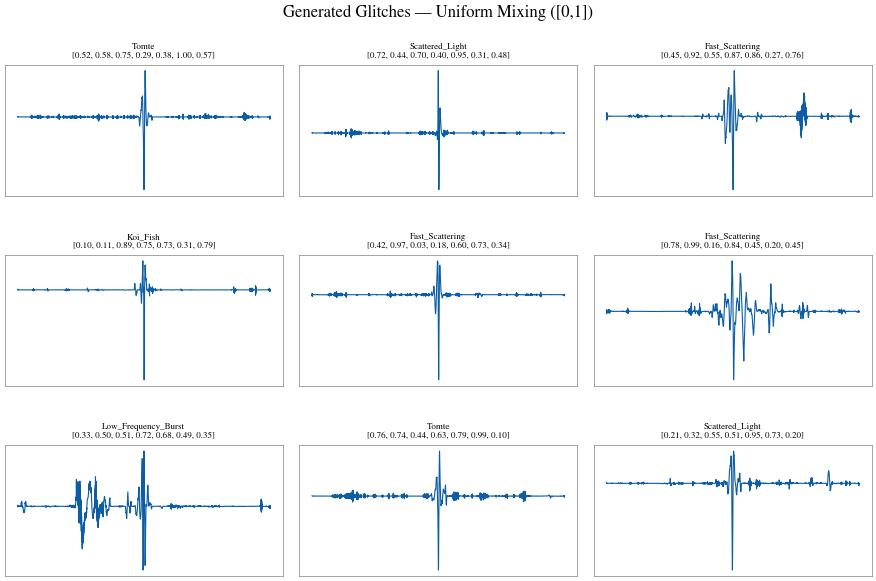

In [22]:
# --- 5a. Grid visualisation — 9 examples of each sampling mode ---------------
SAMPLES_GRID = 9

sigs_sp, cvecs_sp = generate_examples(
    gan, noise_dim=NOISE_DIM, num_classes=NUM_CLASSES,
    num_signals=SAMPLES_GRID, sampling="simplex")
sigs_un, cvecs_un = generate_examples(
    gan, noise_dim=NOISE_DIM, num_classes=NUM_CLASSES,
    num_signals=SAMPLES_GRID, sampling="uniform")


def _mixed_grid(signals, class_vecs, title):
    fig, axes = plt.subplots(3, 3, figsize=(9, 6), sharex=True)
    for ax, sig, cvec in zip(axes.flatten(), signals, class_vecs):
        ax.plot(sig, lw=0.8, color="C0")
        ax.set_xticks([])
        ax.set_yticks([])
        dominant = LABEL_ORDER[np.argmax(cvec)]
        vec_str  = ", ".join(f"{v:.2f}" for v in cvec)
        ax.text(0.5, 1.04, f"{dominant}\n[{vec_str}]",
                transform=ax.transAxes, fontsize=6.5, ha="center", va="bottom")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(pad=1.0, h_pad=2.2)
    safe = title.lower().replace(" ", "_").replace("—", "").replace("(", "").replace(")", "").replace("=", "eq").strip("_")
    plt.savefig(PLOTS_DIR / f"{safe}.pdf", bbox_inches="tight")
    plt.show()


_mixed_grid(sigs_sp, cvecs_sp, "Generated Glitches — Simplex Mixing (sum=1)")
_mixed_grid(sigs_un, cvecs_un, "Generated Glitches — Uniform Mixing ([0,1])")

In [23]:
# --- 5b. Generate vertex / simplex / uniform for UMAP embedding --------------
SAMPLES_PER_TYPE      = 1500
SAMPLES_VERTEX_TOTAL  = (SAMPLES_PER_TYPE // NUM_CLASSES) * NUM_CLASSES  # divisible

sigs_simplex, cvecs_simplex = generate_examples(
    gan, noise_dim=NOISE_DIM, num_classes=NUM_CLASSES,
    num_signals=SAMPLES_PER_TYPE, sampling="simplex")
sigs_uniform, cvecs_uniform = generate_examples(
    gan, noise_dim=NOISE_DIM, num_classes=NUM_CLASSES,
    num_signals=SAMPLES_PER_TYPE, sampling="uniform")
sigs_vertex,  cvecs_vertex  = generate_examples(
    gan, noise_dim=NOISE_DIM, num_classes=NUM_CLASSES,
    num_signals=SAMPLES_VERTEX_TOTAL, sampling="vertex")

y_vertex = np.array(LABEL_ORDER)[np.argmax(cvecs_vertex, axis=1)]

X_mix        = np.concatenate([sigs_vertex,  sigs_simplex, sigs_uniform], axis=0)
domain_labels = np.concatenate([
    np.full(len(sigs_vertex),  "Vertex"),
    np.full(SAMPLES_PER_TYPE,  "Simplex"),
    np.full(SAMPLES_PER_TYPE,  "Uniform"),
])
y_mix = np.concatenate([
    y_vertex,
    np.full(SAMPLES_PER_TYPE, "Simplex"),
    np.full(SAMPLES_PER_TYPE, "Uniform"),
])

print(f"Total: {len(X_mix)}  "
      f"({len(sigs_vertex)} vertex, {SAMPLES_PER_TYPE} simplex, {SAMPLES_PER_TYPE} uniform)")

reducer_mix  = umap.UMAP(n_components=3, random_state=SEED,
                          n_neighbors=30, min_dist=0.2, metric="euclidean")
embedding_mix = reducer_mix.fit_transform(X_mix)
print("UMAP done.")

Total: 4498  (1498 vertex, 1500 simplex, 1500 uniform)


/opt/homebrew/Caskroom/miniforge/base/envs/glitchgan_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


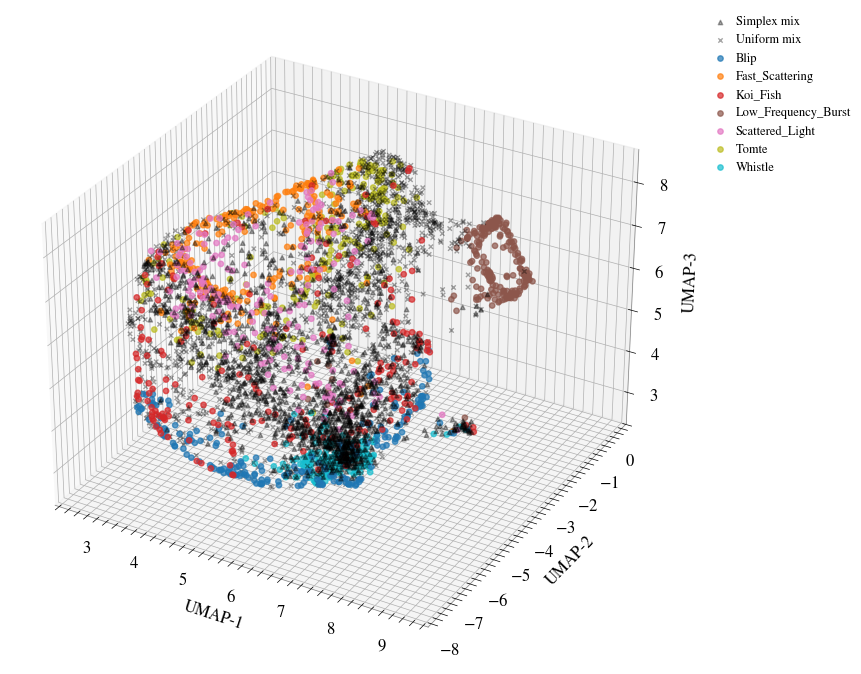

In [24]:
# --- 5c. 3D UMAP: vertex colored by class, simplex/uniform in black ----------
_class_colors_mix = dict(zip(LABEL_ORDER,
                             plt.cm.tab10(np.linspace(0, 1, len(LABEL_ORDER)))))

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")

m_sp = domain_labels == "Simplex"
ax.scatter(embedding_mix[m_sp, 0], embedding_mix[m_sp, 1], embedding_mix[m_sp, 2],
           c="k", marker="^", s=10, alpha=0.35, label="Simplex mix")

m_un = domain_labels == "Uniform"
ax.scatter(embedding_mix[m_un, 0], embedding_mix[m_un, 1], embedding_mix[m_un, 2],
           c="k", marker="x", s=10, alpha=0.35, label="Uniform mix")

for lbl in LABEL_ORDER:
    m = (domain_labels == "Vertex") & (y_mix == lbl)
    ax.scatter(embedding_mix[m, 0], embedding_mix[m, 1], embedding_mix[m, 2],
               c=[_class_colors_mix[lbl]], s=15, alpha=0.7, label=lbl)

ax.set_xlabel("UMAP-1", fontsize=12)
ax.set_ylabel("UMAP-2", fontsize=12)
ax.set_zlabel("UMAP-3", fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "simplex_uniform_umap.pdf", bbox_inches="tight")
plt.show()

In [25]:
# --- 5d. Save UMAP embedding for later reuse ---------------------------------
np.savez_compressed(
    PLOTS_DIR / "simplex_uniform_umap_data.npz",
    embedding=embedding_mix,
    y_all=y_mix,
    domain_labels=domain_labels,
    label_order=np.array(LABEL_ORDER),
)
print(f"Saved → {PLOTS_DIR / 'simplex_uniform_umap_data.npz'}")

Saved → /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/simplex_uniform_umap_data.npz
